In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

%matplotlib inline

# ADAPT THIS TO THE FILEPATH OF YOUR PARQUET FILE #
df = pd.read_parquet('cv.parquet')

print('shape:', df.shape)
print('columns:    ', df.columns.tolist())
print('widths:     ', sorted(df['width'].unique()))
print('batch sizes:', sorted(df['batch_size'].unique()))
print('lrs:        ', sorted(df['lr'].unique()))

shape: (11232540, 14)
columns:     ['iteration', 'gns', 'gns_norm', 'gns_var', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'test_loss', 'test_acc', 'width', 'batch_size', 'lr', 'samples_seen']
widths:      [1.0, 2.0, 4.0]
batch sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
lrs:         [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1]


In [15]:
# ── Configuration ────────────────────────────────────────────────────────────
WIDTH = 2.0                     # 1.0, 2.0, or 4.0
# ── Best LR per batch size ────────────────────────────────────────────────────
results = []
for (bs, lr), group in df[df['width'] == WIDTH].groupby(['batch_size', 'lr']):
    valid = group['val_loss'].dropna()
    if valid.empty:
        continue
    results.append({'batch_size': bs, 'lr': lr, 'final_val_loss': valid.iloc[-1]})

summary = pd.DataFrame(results)
best = summary.loc[summary.groupby('batch_size')['final_val_loss'].idxmin()]
print(best.to_string(index=False))

 batch_size      lr  final_val_loss
         32  0.0001        0.511689
         64  0.0001        0.535331
        128  0.0010        0.551933
        256  0.0010        0.511715
        512  0.0010        0.489449
       1024  0.0010        0.462780
       2048  0.0010        0.462956
       4096  0.0010        0.478603
       8192  0.0010        0.503743
      16384  0.0010        0.581557


In [16]:
BASE_SMOOTH_BS = 50000          # adaptive smoothing threshold

# (batch_size, lr, label, color)
selected_configs = [
    (128,  0.001,  r"BS=$2^{7}$, LR=$10^{-3}$",  "#0077BB"),
    (256,  0.001,  r"BS=$2^{8}$, LR=$10^{-3}$",  "#EE7733"),
    (512,  0.001,  r"BS=$2^{9}$, LR=$10^{-3}$",  "#009988"),
    (1024, 0.001,  r"BS=$2^{10}$, LR=$10^{-3}$", "#CC3311"),
    (2048, 0.001,  r"BS=$2^{11}$, LR=$10^{-3}$", "#EE3377"),
    # different validation loss example
    (2048, 0.1,    r"BS=$2^{11}$, LR=$10^{-1}$", "#CCCCCC"),
]

def smooth(values, window):
    if window <= 1:
        return values
    out = np.convolve(values, np.ones(window) / window, mode='valid')
    pad = [np.mean(values[:i+1]) for i in range(len(values) - len(out))]
    return np.concatenate([pad, out])

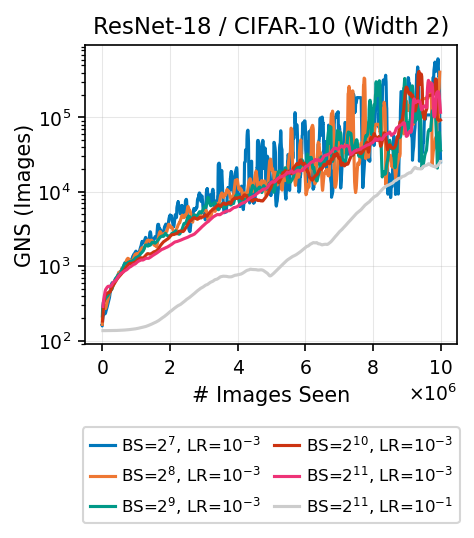

In [ ]:
# ── Plot settings ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'lines.linewidth': 1.5,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

X_COL = 3.25
fig, ax = plt.subplots(figsize=(X_COL, X_COL * 1.21))

for bs, lr, label, color in selected_configs:
    run = df[
        (df['width'] == WIDTH) &
        (df['batch_size'] == bs) & (df['lr'] == lr) &
        df['gns'].notna() & np.isfinite(df['gns']) & (df['gns'] < 1e6)
    ].sort_values('samples_seen')

    if run.empty:
        print(f'No data: {label}')
        continue

    window = int(BASE_SMOOTH_BS / bs) if bs < BASE_SMOOTH_BS else 1
    gns = smooth(run['gns'].values, window)

    ax.plot(run['samples_seen'].values, gns, color=color, label=label)

ax.set_xlabel('# Images Seen')
ax.set_ylabel('GNS (Images)', labelpad=1)
ax.set_title('ResNet-18 / CIFAR-10 (Width 2)', fontweight='medium')
ax.set_yscale('log')

ax.xaxis.set_major_locator(FixedLocator([0, 2e6, 4e6, 6e6, 8e6, 10e6]))
ax.xaxis.set_major_formatter(FixedFormatter(['0', '2', '4', '6', '8', '10']))
ax.text(1.0, -0.13, r'$\times 10^6$', transform=ax.transAxes, fontsize=9, ha='right', va='top')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=2, columnspacing=0.8, handlelength=1.5,
          handletextpad=0.4, frameon=True)

fig.tight_layout()
plt.savefig('cv_temperature_comparison.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()